In [32]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Concatenate, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import ResNet50

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
TensorFlow version: 2.19.0


In [33]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Ensure your kaggle.json is uploaded to the Colab environment!
!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

In [34]:
!kaggle datasets download -d mehradaria/leukemia
!unzip -q leukemia.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
leukemia.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/Original/Benign/WBC-Benign-001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [46]:
# ==========================================
# 3. STRICTLY ISOLATED DATA PARSING
# ==========================================
dataset_root = "/content/dataset/Original"
categories = {"Benign": 0, "Early": 1, "Pre": 1, "Pro": 1}

# Load Hospital B's fixed Pathology Database
csv_path = "/content/pathology_ds.csv"
tabular_df = pd.read_csv(csv_path)

image_data = []
tabular_data = []
patient_counter = 1
np.random.seed(42)

In [47]:
# Separate available patient IDs by diagnosis to ensure accurate mapping
healthy_ids = tabular_df[tabular_df['Diagnosis'] == 0]['patient_id'].tolist()
leukemia_ids = tabular_df[tabular_df['Diagnosis'] == 1]['patient_id'].tolist()


if os.path.exists(dataset_root):
    for folder, label in categories.items():
        folder_path = os.path.join(dataset_root, folder)
        if not os.path.exists(folder_path): continue

        for img_name in os.listdir(folder_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                img_path = os.path.join(folder_path, img_name)

                # Match the image to the correct clinical row
                if label == 0 and len(healthy_ids) > 0:
                    patient_id = healthy_ids.pop(0)
                elif label == 1 and len(leukemia_ids) > 0:
                    patient_id = leukemia_ids.pop(0)
                else:
                    # If we run out of matching CSV rows for this category, skip the image
                    continue

                # 🖼️ HOSPITAL A's DATABASE (Images Only)
                image_data.append({
                    "patient_id": patient_id,
                    "image_path": img_path,
                    "Label": label
                })

image_df = pd.DataFrame(image_data)

# Clean up tabular_df to strictly match the images we successfully mapped
matched_ids = image_df['patient_id'].tolist()
tabular_df = tabular_df[tabular_df['patient_id'].isin(matched_ids)].reset_index(drop=True)

image_df = image_df.sort_values('patient_id').reset_index(drop=True)
tabular_df = tabular_df.sort_values('patient_id').reset_index(drop=True)

In [48]:
# ==========================================
# SPLIT AND SCALE (Preventing Data Leakage)
# ==========================================

# 1. Train/Test Split (MUST happen before scaling)
# Same random_state guarantees IDs align perfectly on the server without sharing data
train_img, test_img = train_test_split(image_df, test_size=0.2, random_state=42)
train_tab, test_tab = train_test_split(tabular_df, test_size=0.2, random_state=42)

# Create explicit copies to avoid Pandas 'SettingWithCopyWarning'
train_tab = train_tab.copy()
test_tab = test_tab.copy()

# 2. Scale Hospital B's tabular data (Locally within Hospital B)
print("-> Hospital B: Scaling clinical features securely...")

# Isolate just the numerical clinical columns (ignore ID and Diagnosis)
feature_cols = [col for col in tabular_df.columns if col not in ['patient_id', 'Diagnosis']]

scaler = StandardScaler()

# FIT ONLY on the training data, then transform it
train_tab[feature_cols] = scaler.fit_transform(train_tab[feature_cols])

# TRANSFORM the testing data using the rules learned from the training data
test_tab[feature_cols] = scaler.transform(test_tab[feature_cols])

-> Hospital B: Scaling clinical features securely...


In [49]:
# ==========================================
# 4. ISOLATED BATCH GENERATORS (The Privacy Fix)
# ==========================================
def get_hospital_a_batch(batch_df, target_size=(224, 224)):
    """Hospital A ONLY touches the images."""
    batch_images = []
    for _, row in batch_df.iterrows():
        try:
            img = load_img(row['image_path'], target_size=target_size)
            img = img_to_array(img) / 255.0
        except:
            img = np.zeros((*target_size, 3))
        batch_images.append(img)
    return np.array(batch_images)

In [50]:
def get_hospital_b_batch(batch_df):
    """Hospital B ONLY touches the CSV rows."""
    return batch_df.drop(['patient_id', 'Diagnosis'], axis=1).values

In [51]:
# ==========================================
# 5. ISOLATED NEURAL NETWORKS
# ==========================================
# 🏥 HOSPITAL A: Image Feature Extractor
def build_hospital_a_resnet():
    img_input = Input(shape=(224, 224, 3), name="hospital_a_input")
    base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=img_input)
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    output = Dense(128, activation='relu', name="smashed_images")(x)
    return Model(inputs=img_input, outputs=output, name="Hospital_A_Model")

In [52]:
# 🏥 HOSPITAL B: Tabular Feature Extractor
def build_hospital_b_mlp(input_dim=10):
    tab_input = Input(shape=(input_dim,), name="hospital_b_input")
    x = Dense(64, activation='relu')(tab_input)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    output = Dense(32, activation='relu', name="smashed_tabular")(x)
    return Model(inputs=tab_input, outputs=output, name="Hospital_B_Model")

In [53]:
def build_server_fusion():
    input_a = Input(shape=(128,), name="received_from_A")
    input_b = Input(shape=(32,), name="received_from_B")
    merged = Concatenate()([input_a, input_b])
    x = Dense(64, activation='relu')(merged)
    x = Dropout(0.3)(x)
    final_output = Dense(1, activation='sigmoid', name="global_diagnosis")(x)

    server_model = Model(inputs=[input_a, input_b], outputs=final_output, name="Server_Model")
    server_model.compile(optimizer=Adam(learning_rate=0.001),
                         loss='binary_crossentropy',
                         metrics=['accuracy'])
    return server_model

In [56]:
# ==========================================
# 5. INITIALIZE ISOLATED NETWORKS
# ==========================================

num_clinical_features = train_tab.drop(['patient_id', 'Diagnosis'], axis=1).shape[1]
print(f"📊 Hospital B: Configuring MLP for {num_clinical_features} input features.")

model_A = build_hospital_a_resnet()
model_B = build_hospital_b_mlp(input_dim=num_clinical_features)
server_model = build_server_fusion()

📊 Hospital B: Configuring MLP for 12 input features.


In [57]:
# ==========================================
# 6. SPLIT LEARNING SIMULATION (The Privacy Wall)
# ==========================================
epochs = 5
batch_size = 32
num_samples = len(train_tab)
# Calculate total steps for the progress bar
steps_per_epoch = int(np.ceil(num_samples / batch_size))

print("\n🚀 Starting Vertical Federated Learning (SplitNN) Simulation...")

# Lists to save history for plotting later
history_loss = []
history_acc = []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    indices = np.arange(num_samples)
    np.random.shuffle(indices)

    epoch_loss, epoch_acc = [], []

    # ⏱️ Initialize the live Keras Progress Bar
    progbar = tf.keras.utils.Progbar(steps_per_epoch, stateful_metrics=['loss', 'accuracy'])
    step_counter = 0

    for start_idx in range(0, num_samples, batch_size):
        batch_idx = indices[start_idx : start_idx + batch_size]

        # 🔐 CLIENT SIDE (Local Feature Extraction)
        # Hospital A extracts 128 numbers
        raw_images = get_hospital_a_batch(train_img.iloc[batch_idx])
        smashed_a = model_A.predict(raw_images, verbose=0)

        # Hospital B extracts 32 numbers
        raw_tabular = get_hospital_b_batch(train_tab.iloc[batch_idx])
        smashed_b = model_B.predict(raw_tabular, verbose=0)

        # ☁️ SERVER SIDE (Fusion and Training)
        # The Server ONLY trains on the mathematical "smashed" vectors.
        labels = train_tab.iloc[batch_idx]['Diagnosis'].values
        loss, accuracy = server_model.train_on_batch(
            x=[smashed_a, smashed_b],
            y=labels
        )

        epoch_loss.append(loss)
        epoch_acc.append(accuracy)

    print(f"Server Loss: {np.mean(epoch_loss):.4f} | Server Accuracy: {np.mean(epoch_acc):.4f}")

    # Save the final average metrics for this epoch to plot later
    history_loss.append(np.mean(epoch_loss))
    history_acc.append(np.mean(epoch_acc))


🚀 Starting Vertical Federated Learning (SplitNN) Simulation...

Epoch 1/5


Server Loss: 0.4516 | Server Accuracy: 0.7712

Epoch 2/5
Server Loss: 0.2616 | Server Accuracy: 0.8872

Epoch 3/5
Server Loss: 0.1816 | Server Accuracy: 0.9301

Epoch 4/5
Server Loss: 0.1375 | Server Accuracy: 0.9502

Epoch 5/5
Server Loss: 0.1104 | Server Accuracy: 0.9614



📊 FINAL GLOBAL MODEL EVALUATION
Extracting test features from Hospital A...
Extracting test features from Hospital B...
Server computing final predictions...

✅ Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       1.00      1.00      1.00       124
Leukemia (1)       1.00      1.00      1.00       528

    accuracy                           1.00       652
   macro avg       1.00      1.00      1.00       652
weighted avg       1.00      1.00      1.00       652



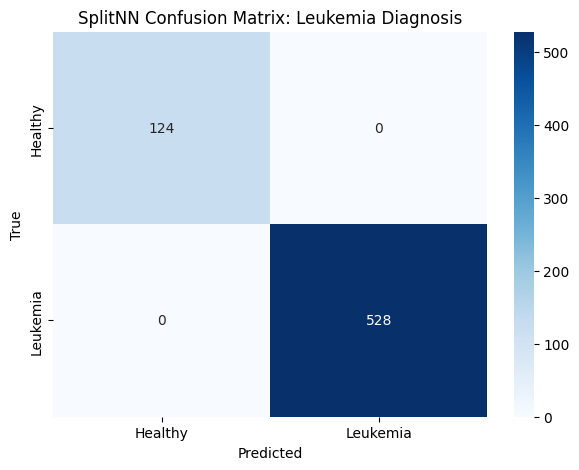

In [58]:
# ==========================================
# 7. GLOBAL EVALUATION & METRICS
# ==========================================

print("\n" + "="*50)
print("📊 FINAL GLOBAL MODEL EVALUATION")
print("="*50)

print("Extracting test features from Hospital A...")
test_images_raw = get_hospital_a_batch(test_img)
test_smashed_a = model_A.predict(test_images_raw, verbose=0)

print("Extracting test features from Hospital B...")
test_tabular_raw = get_hospital_b_batch(test_tab)
test_smashed_b = model_B.predict(test_tabular_raw, verbose=0)

test_labels = test_tab['Diagnosis'].values

print("Server computing final predictions...")
y_pred_probs = server_model.predict([test_smashed_a, test_smashed_b], verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("\n✅ Classification Report:")
print(classification_report(test_labels, y_pred, target_names=["Healthy (0)", "Leukemia (1)"]))

cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Healthy", "Leukemia"],
            yticklabels=["Healthy", "Leukemia"])
plt.title("SplitNN Confusion Matrix: Leukemia Diagnosis")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()